<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


In [1]:
# The required libraries are imported below.
# No package-installation command is needed when they are already available
# in the Jupyter environment.


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [2]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [3]:
local_candidates = [
    Path("dataset_part_2.csv"),
    Path("./dataset_part_2.csv"),
]

dataset_url = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)

df = None

for local_file in local_candidates:
    if local_file.exists():
        df = pd.read_csv(local_file)
        print(f"Loaded local dataset: {local_file.resolve()}")
        break

if df is None:
    try:
        response = requests.get(dataset_url, timeout=60)
        response.raise_for_status()
        df = pd.read_csv(StringIO(response.text))
        print("Downloaded the official IBM dataset_part_2.csv successfully.")
    except requests.RequestException as error:
        raise RuntimeError(
            "The dataset could not be downloaded. Place dataset_part_2.csv "
            "in the same folder as this notebook and run the cell again."
        ) from error

required_columns = {
    "FlightNumber", "PayloadMass", "Orbit", "LaunchSite", "Class",
    "Flights", "GridFins", "Reused", "Legs", "LandingPad",
    "Block", "ReusedCount", "Serial", "Date"
}

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(
        f"The dataset is missing required columns: {sorted(missing_columns)}"
    )

# Ensure plotting and modelling columns use suitable types.
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Class"] = pd.to_numeric(df["Class"], errors="raise").astype(int)

print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
df.head(10)


Loaded local dataset: /Users/dalalalhabad/Desktop/dataset_part_2.csv
Dataset shape: 90 rows and 18 columns


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857,0
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857,1
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857,1
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857,0
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


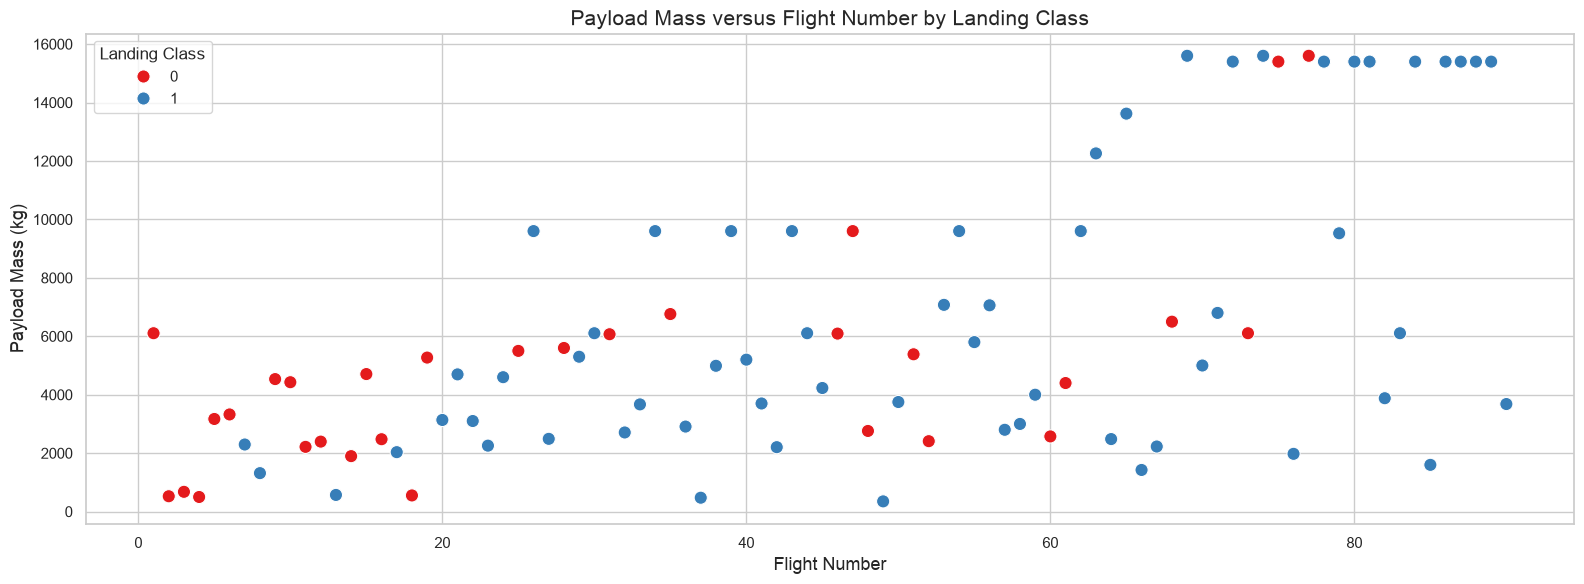

In [4]:
plt.figure(figsize=(16, 6))
sns.scatterplot(
    data=df,
    x="FlightNumber",
    y="PayloadMass",
    hue="Class",
    palette="Set1",
    s=90
)
plt.xlabel("Flight Number", fontsize=13)
plt.ylabel("Payload Mass (kg)", fontsize=13)
plt.title("Payload Mass versus Flight Number by Landing Class", fontsize=15)
plt.legend(title="Landing Class")
plt.tight_layout()
plt.show()


Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


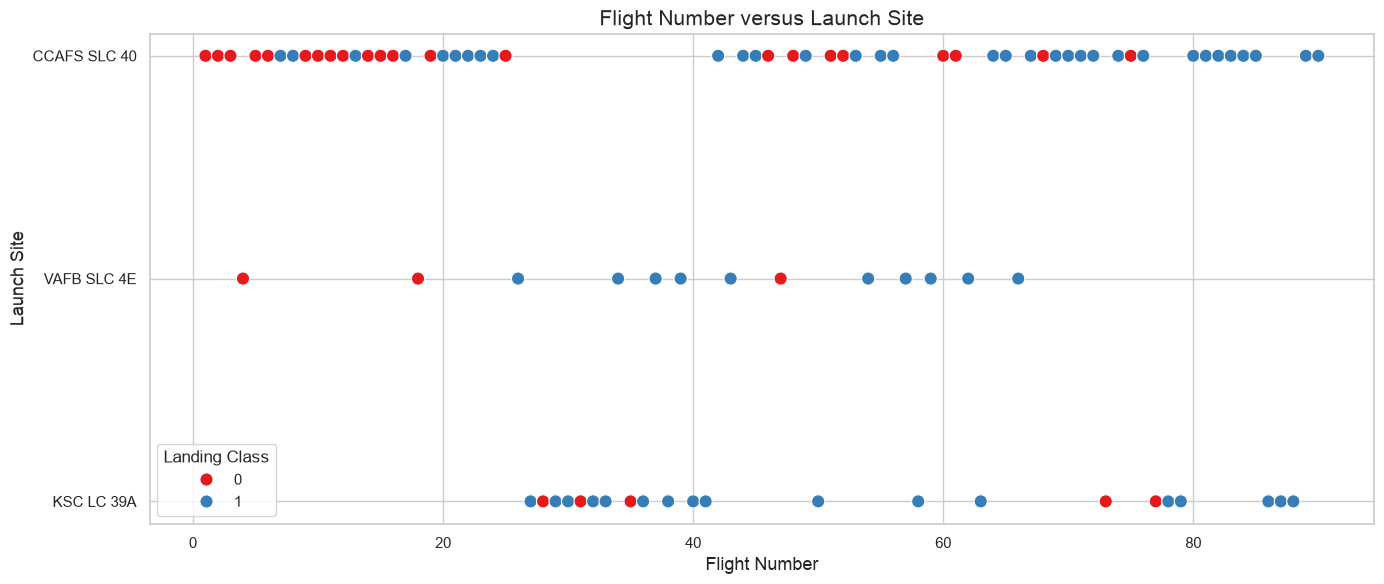

,Launches,First_Flight,Last_Flight,Success_Rate
LaunchSite,,,,
KSC LC 39A,22,27,88,0.772727
VAFB SLC 4E,13,4,66,0.769231
CCAFS SLC 40,55,1,90,0.600000


In [5]:
# TASK 1: Flight Number versus Launch Site.
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=df,
    x="FlightNumber",
    y="LaunchSite",
    hue="Class",
    palette="Set1",
    s=90
)
plt.xlabel("Flight Number", fontsize=13)
plt.ylabel("Launch Site", fontsize=13)
plt.title("Flight Number versus Launch Site", fontsize=15)
plt.legend(title="Landing Class")
plt.tight_layout()
plt.show()

site_flight_summary = (
    df.groupby("LaunchSite")
      .agg(
          Launches=("FlightNumber", "count"),
          First_Flight=("FlightNumber", "min"),
          Last_Flight=("FlightNumber", "max"),
          Success_Rate=("Class", "mean")
      )
      .sort_values("Success_Rate", ascending=False)
)

site_flight_summary


Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


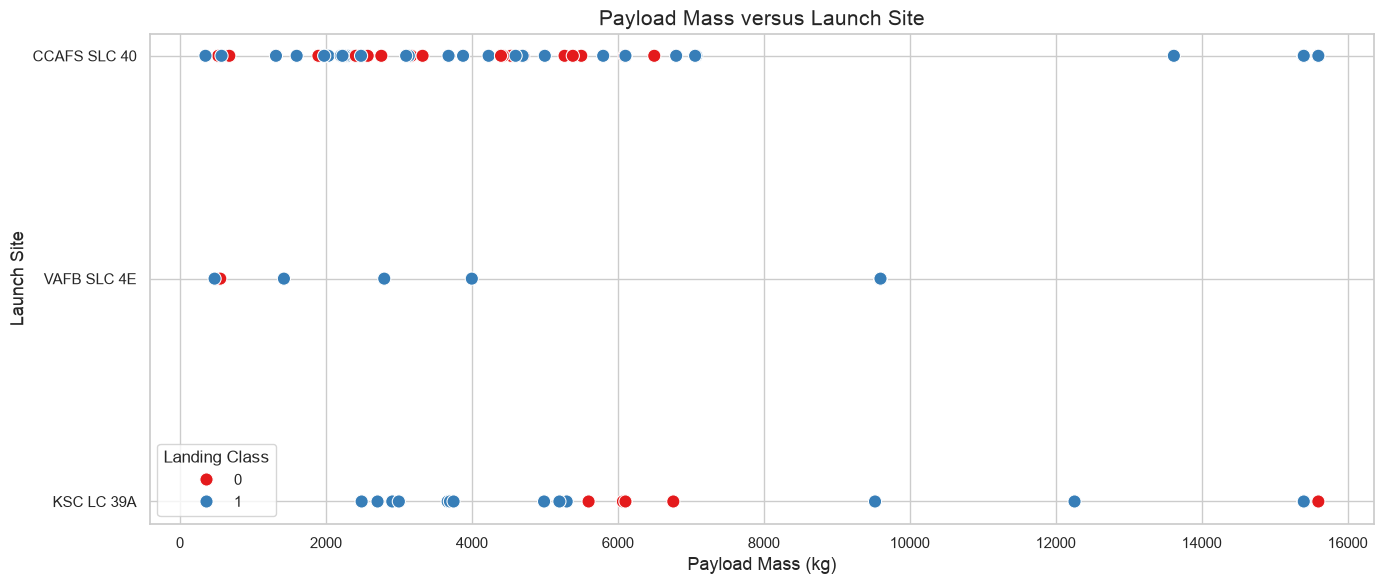

,Launches,Minimum_Payload,Maximum_Payload,Average_Payload,Success_Rate
LaunchSite,,,,,
CCAFS SLC 40,55,350.0,15600.0,5548.21,0.60
KSC LC 39A,22,2490.0,15600.0,7606.45,0.77
VAFB SLC 4E,13,475.0,9600.0,5919.46,0.77


In [6]:
# TASK 2: Payload Mass versus Launch Site.
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=df,
    x="PayloadMass",
    y="LaunchSite",
    hue="Class",
    palette="Set1",
    s=90
)
plt.xlabel("Payload Mass (kg)", fontsize=13)
plt.ylabel("Launch Site", fontsize=13)
plt.title("Payload Mass versus Launch Site", fontsize=15)
plt.legend(title="Landing Class")
plt.tight_layout()
plt.show()

payload_site_summary = (
    df.groupby("LaunchSite")
      .agg(
          Launches=("PayloadMass", "count"),
          Minimum_Payload=("PayloadMass", "min"),
          Maximum_Payload=("PayloadMass", "max"),
          Average_Payload=("PayloadMass", "mean"),
          Success_Rate=("Class", "mean")
      )
      .round(2)
)

payload_site_summary


Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


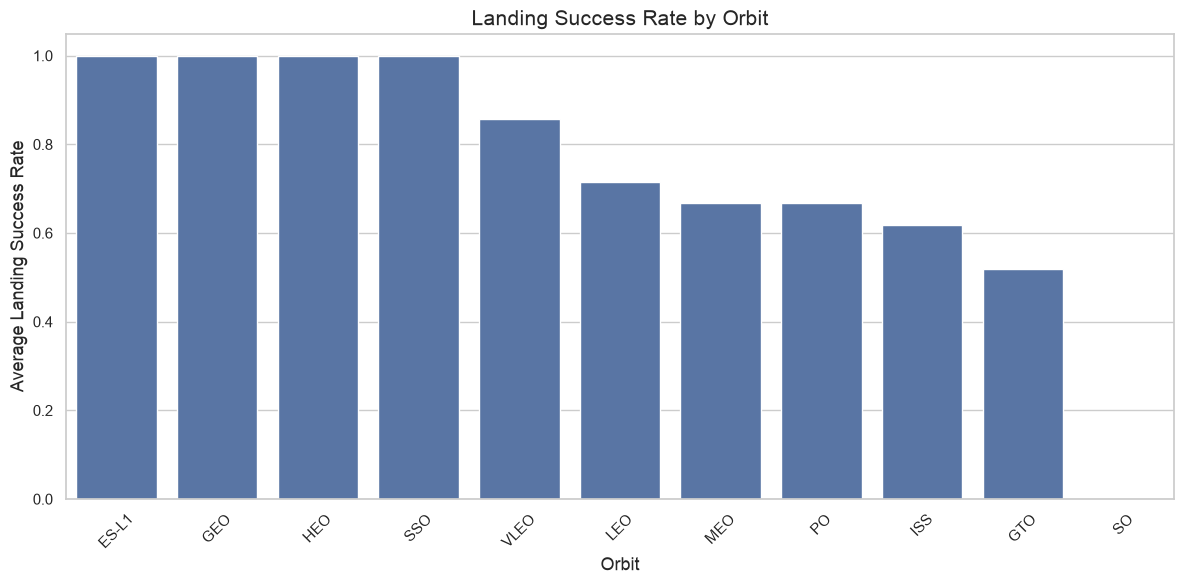

,Orbit,SuccessRate
0,ES-L1,1.000000
1,GEO,1.000000
3,HEO,1.000000
9,SSO,1.000000
10,VLEO,0.857143
5,LEO,0.714286
6,MEO,0.666667
7,PO,0.666667
4,ISS,0.619048
2,GTO,0.518519


In [7]:
# TASK 3: Average landing success rate for each orbit.
orbit_success_rate = (
    df.groupby("Orbit", as_index=False)["Class"]
      .mean()
      .rename(columns={"Class": "SuccessRate"})
      .sort_values("SuccessRate", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=orbit_success_rate,
    x="Orbit",
    y="SuccessRate"
)
plt.xlabel("Orbit", fontsize=13)
plt.ylabel("Average Landing Success Rate", fontsize=13)
plt.title("Landing Success Rate by Orbit", fontsize=15)
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

orbit_success_rate


Analyze the ploted bar chart try to find which orbits have high sucess rate.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


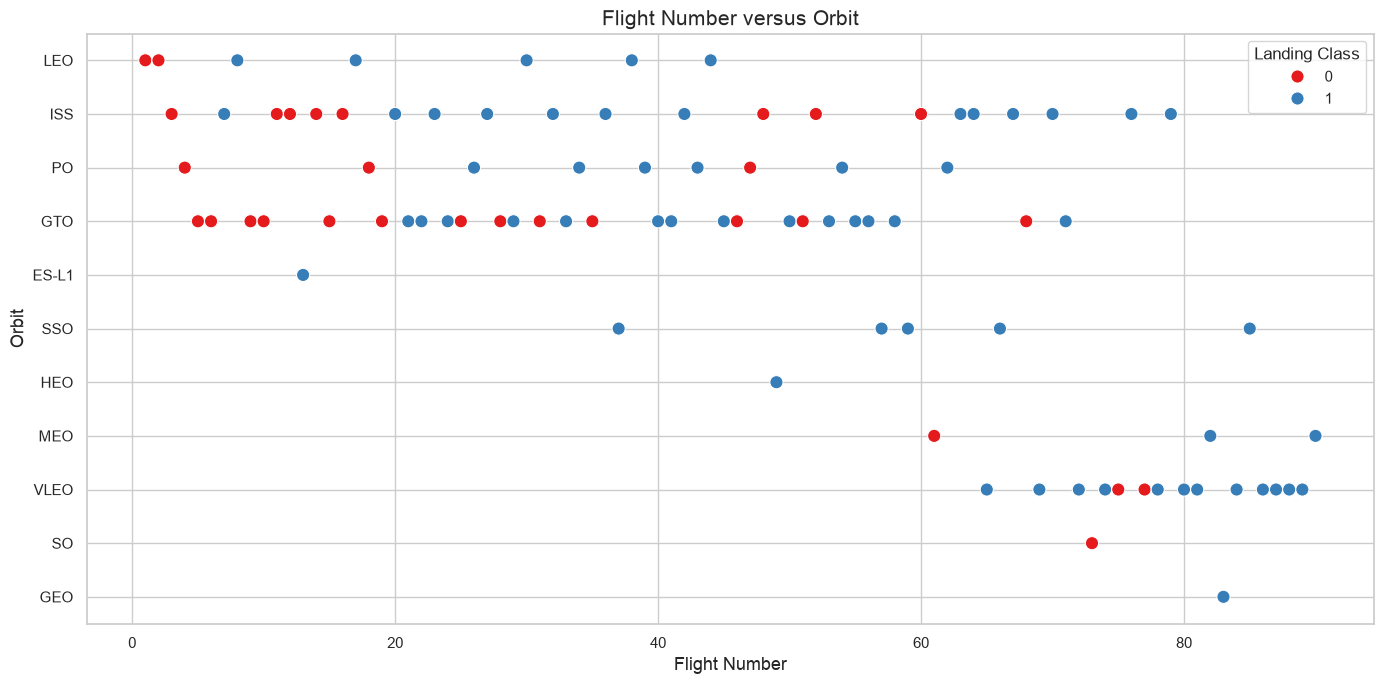

In [8]:
# TASK 4: Flight Number versus Orbit.
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df,
    x="FlightNumber",
    y="Orbit",
    hue="Class",
    palette="Set1",
    s=90
)
plt.xlabel("Flight Number", fontsize=13)
plt.ylabel("Orbit", fontsize=13)
plt.title("Flight Number versus Orbit", fontsize=15)
plt.legend(title="Landing Class")
plt.tight_layout()
plt.show()


You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


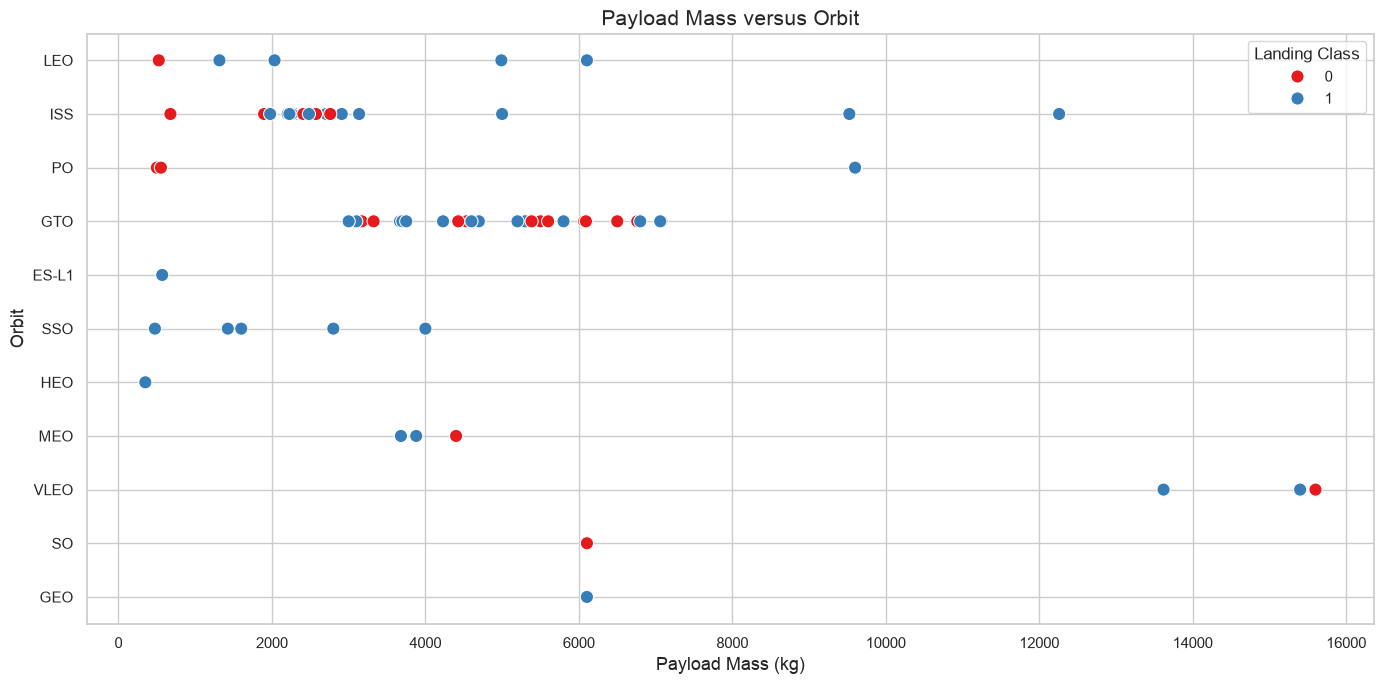

In [9]:
# TASK 5: Payload Mass versus Orbit.
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=df,
    x="PayloadMass",
    y="Orbit",
    hue="Class",
    palette="Set1",
    s=90
)
plt.xlabel("Payload Mass (kg)", fontsize=13)
plt.ylabel("Orbit", fontsize=13)
plt.title("Payload Mass versus Orbit", fontsize=15)
plt.legend(title="Landing Class")
plt.tight_layout()
plt.show()


With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [10]:
def extract_year(date_series):
    """Extract calendar years from a pandas Series of dates."""
    parsed_dates = pd.to_datetime(date_series, errors="coerce")
    return parsed_dates.dt.year


df["Year"] = extract_year(df["Date"])

if df["Year"].isna().any():
    print(
        "Warning:",
        int(df["Year"].isna().sum()),
        "rows contain invalid or missing dates."
    )

df[["Date", "Year"]].head()


,Date,Year
0,2010-06-04,2010
1,2012-05-22,2012
2,2013-03-01,2013
3,2013-09-29,2013
4,2013-12-03,2013


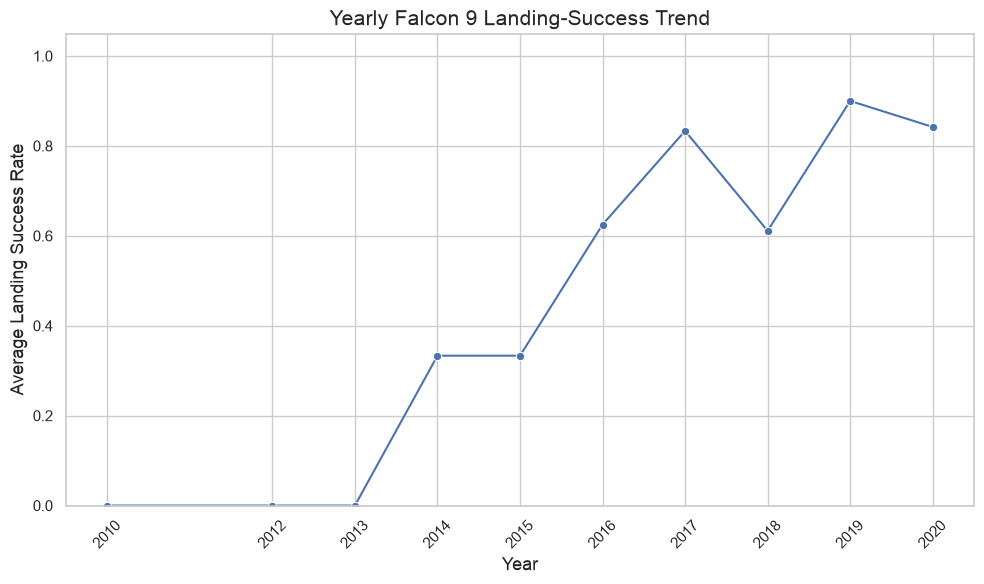

,Year,SuccessRate
0,2010,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.333333
4,2015,0.333333
5,2016,0.625000
6,2017,0.833333
7,2018,0.611111
8,2019,0.900000
9,2020,0.842105


In [11]:
# TASK 6: Plot the yearly landing-success trend.
yearly_success = (
    df.dropna(subset=["Year"])
      .groupby("Year", as_index=False)["Class"]
      .mean()
      .rename(columns={"Class": "SuccessRate"})
      .sort_values("Year")
)

yearly_success["Year"] = yearly_success["Year"].astype(int)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=yearly_success,
    x="Year",
    y="SuccessRate",
    marker="o"
)
plt.xlabel("Year", fontsize=13)
plt.ylabel("Average Landing Success Rate", fontsize=13)
plt.title("Yearly Falcon 9 Landing-Success Trend", fontsize=15)
plt.ylim(0, 1.05)
plt.xticks(yearly_success["Year"].unique(), rotation=45)
plt.tight_layout()
plt.show()

yearly_success


You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [12]:
feature_columns = [
    "FlightNumber", "PayloadMass", "Orbit", "LaunchSite", "Flights",
    "GridFins", "Reused", "Legs", "LandingPad", "Block",
    "ReusedCount", "Serial"
]

features = df[feature_columns].copy()

print("Original feature-data shape:", features.shape)
features.head()


Original feature-data shape: (90, 12)


,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [13]:
# TASK 7: One-hot encode the categorical columns.
categorical_columns = [
    "Orbit",
    "LaunchSite",
    "LandingPad",
    "Serial"
]

features_one_hot = pd.get_dummies(
    features,
    columns=categorical_columns,
    prefix=categorical_columns,
    dtype=float
)

# Convert Boolean columns, when present, into numerical values.
boolean_columns = features_one_hot.select_dtypes(include="bool").columns
features_one_hot[boolean_columns] = (
    features_one_hot[boolean_columns].astype(float)
)

print("One-hot encoded feature shape:", features_one_hot.shape)
features_one_hot.head()


One-hot encoded feature shape: (90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,525.000000,1,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,677.000000,1,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,500.000000,1,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,3170.000000,1,0.0,0.0,0.0,1.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [14]:
# TASK 8: Cast every feature column to float64.
features_one_hot = features_one_hot.astype("float64")

non_float_columns = (
    features_one_hot.dtypes[
        features_one_hot.dtypes != "float64"
    ].index.tolist()
)

if non_float_columns:
    raise TypeError(
        f"These columns were not converted to float64: {non_float_columns}"
    )

print("All feature columns were converted to float64.")
print("Final feature-data shape:", features_one_hot.shape)
features_one_hot.dtypes.value_counts()


All feature columns were converted to float64.
Final feature-data shape: (90, 80)


float64    80
Name: count, dtype: int64

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


In [15]:
# Export the prepared features for the machine-learning notebook.
output_file = "dataset_part_3.csv"
features_one_hot.to_csv(output_file, index=False)

print(f"Saved {output_file} successfully.")
print("Exported shape:", features_one_hot.shape)

# Final validation.
if features_one_hot.empty:
    raise ValueError("The feature DataFrame is empty.")

if features_one_hot.isna().any().any():
    missing_total = int(features_one_hot.isna().sum().sum())
    raise ValueError(
        f"The feature DataFrame contains {missing_total} missing values."
    )

print("Final validation passed.")


Saved dataset_part_3.csv successfully.
Exported shape: (90, 80)
Final validation passed.


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
